# VBT Semantic Search Smoke Test
## Vijñāna Bhairava Tantra × BGE-M3 × pgvector

This notebook exercises the full **chunk-embed** pipeline with a curated subset of the Vijñāna Bhairava Tantra (VBT) — 15 Sanskrit verses spanning 6 practice domains, each paired with an English translation (30 chunks total).

**Pipeline:** Sanskrit/English verses → BGE-M3 embeddings (1024-dim) → PostgreSQL + pgvector → cosine similarity search

**Visualizations:**
1. Pairwise similarity heatmap — do thematic domains cluster?
2. Cross-lingual similarity matrix — does the diagonal dominate?
3. PCA projection — 2D scatter of all 30 embeddings by domain
4. Retrieval bar charts — English query → ranked Sanskrit results
5. Reverse retrieval bar charts — Sanskrit query → ranked English translations
6. Full-verse cross-lingual retrieval table — Sanskrit verse → own translation rank

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import psycopg
from pgvector.psycopg import register_vector

from chunk_embed.parse import parse_chunks
from chunk_embed.embed import BgeM3Embedder, embed_chunks
from chunk_embed.store import ensure_schema, upsert_document, insert_chunks, search_chunks

sns.set_theme(style="whitegrid", font_scale=1.1)
DB_URL = "postgresql://localhost/chunk_embed_test"

## 1. Verse corpus

15 curated VBT verses across 6 practice domains, sourced from `~/Projects/sa-embedding/vbt_corpus.py`.

In [2]:
VERSES = {
    "dialogue": {
        "sa": "भैरव उवाच ।",
        "en": "Bhairava said:",
        "domain": "Dialogue",
    },
    "breath_ascending": {
        "sa": "ऊर्ध्वे प्राणो ह्य् अधो जीवो विसर्गात्मा परोच्चरेत् / उत्पत्तिद्वितयस्थाने भरणाद् भरिता स्थितिः",
        "en": "Upwards moves the breath, downwards the living soul; their movement brings forth creation and dissolution. In these two places of origin, sustenance arises from their filling, which is existence.",
        "domain": "Prāṇa",
    },
    "breath_middle": {
        "sa": "मरुतो ऽन्तर् बहिर् वापि वियद्युग्मानिवर्तनात् / भैरवी भैरवस्येत्थं भैरवो व्यज्यते वपुः",
        "en": "When the power that is of the nature of air neither moves outward nor inward, but remains expanded; in that state of perfect non-duality in the center, there arises the true form of Bhairava.",
        "domain": "Prāṇa",
    },
    "sound_anahata": {
        "sa": "अनाहते पात्रकर्णे ऽभग्नशब्दे सरिद्द्रुते / शब्दब्रह्मणि निष्णातः परं ब्रह्माधिगच्छति",
        "en": "One who is immersed in the soundless sound, who hears the unbroken current like a flowing river within the inner ear, who is steadfast in the sound-brahman, attains the supreme Brahman.",
        "domain": "Nāda",
    },
    "sound_instruments": {
        "sa": "तन्त्र्यादिवाद्यशब्देषु दीर्घेषु क्रमसंस्थितेः / अनन्यचेताः प्रत्यन्ते परव्योमवपुर् भवेत्",
        "en": "When, amidst the sustained and successive sounds of stringed and other musical instruments, one's mind remains unwaveringly focused upon the end of each sound, one attains the infinite expanse of the supreme ether.",
        "domain": "Nāda",
    },
    "void_body_sky": {
        "sa": "तनूदेशे शून्यतैव क्षणमात्रं विभावयेत् / निर्विकल्पं निर्विकल्पो निर्विकल्पस्वरूपभाक्",
        "en": "For a moment, let one contemplate emptiness in the body's domain; Being thought-free, one becomes thought-free and attains the very essence of thought-free being.",
        "domain": "Śūnyatā",
    },
    "void_triple": {
        "sa": "पृष्ठशून्यं मूलशून्यं हृच्छून्यं भावयेत् स्थिरम् / युगपन् निर्विकल्पत्वान् निर्विकल्पोदयस् ततः",
        "en": "Contemplate firmly on the state where the back is void, the root is void, and the heart is void; At once, due to the absence of alternatives, arises the dawn of non-duality.",
        "domain": "Śūnyatā",
    },
    "bliss_union": {
        "sa": "शक्तिसंगमसंक्षुब्धशक्त्यावेशावसानिकम् / यत् सुखं ब्रह्मतत्त्वस्य तत् सुखं स्वाक्यम् उच्यते",
        "en": "The joy that arises from the union and culmination of energies, from the stirring and ultimate immersion in power—that is the bliss of the Brahman principle; such bliss is called one's own true bliss.",
        "domain": "Ānanda",
    },
    "bliss_meeting": {
        "sa": "लेहनामन्थनकोटैः स्त्रीसुखस्य भरात् स्मृतेः / शक्त्यभावे ऽपि देवेशि भावद् एवं महासुखम्",
        "en": "When great joy is attained, or a beloved friend is seen after a long time, contemplate the surge of bliss that arises, merge into it, and let your mind become one with that.",
        "domain": "Ānanda",
    },
    "gaze_sky": {
        "sa": "निरालम्बं सथिरं शून्यम् अम्बरं यावद् आश्रयेत् / सम्पत्स्यते दृशम् तत्र मेरुपृष्ठाव्लम्बनम्",
        "en": "Gazing unceasingly at the clear sky, with the mind stilled, O Goddess, in that very moment one attains the form of Bhairava.",
        "domain": "Dṛṣṭi",
    },
    "mind_unsupported": {
        "sa": "निराधारं मनः कृत्वा विकल्पान् न विकल्पयेत् / तदात्मपरमात्मत्वे भैरवो मृगलोचने",
        "en": "Having made the mind unsupported, let one not entertain any thoughts; in that identity of self and supreme self, O gazelle-eyed one, is the state of Bhairava.",
        "domain": "Manas",
    },
    "nondual_i_am_shiva": {
        "sa": "सर्वज्ञः सर्वकर्ता च व्यापकः परमेश्वरः / स एवाहं शैवधर्मा इति दार्ढ्याच् छिवो भवेत्",
        "en": "He who knows all, does all, all-pervading, the Supreme Lord—He indeed am I, steadfast in Shaiva dharma; thus, by firmness, one becomes Shiva.",
        "domain": "Advaita",
    },
    "nondual_equal": {
        "sa": "समः शत्रौ च मित्रे च समो मानावमानयोः / ब्रह्मणः परिपूर्णत्वाद् इति ज्ञात्वा सुखी भवेत्",
        "en": "He who is equal toward both enemy and friend, who remains the same in honor and dishonor—knowing that the Self is complete like Brahman—such a person becomes truly happy.",
        "domain": "Advaita",
    },
    "worship_true": {
        "sa": "न वह्निर् न च तत्रोर्मिर् न स्वरूपं मरीचिषु / शैवस्यैव स्वरूपं तद् विमलं विश्वपूरणम्",
        "en": "Worship is not with flowers and the like; it is the firm intent made upon the attributeless vast ether of consciousness. That alone is worship—when, with devotion, one's mind dissolves therein.",
        "domain": "Ritual",
    },
    "bliss_vikalpa_free": {
        "sa": "अन्तःस्वानुभवानन्दा विकल्पोन्मुक्तगोचरा / यावस्था भरिताकारा भैरवी भैरवात्मनः",
        "en": "Internal self direct experiential bliss, free from the conceptualization domain; that state full of bhairavī forms. [This is] the nature of bhairava.",
        "domain": "Ānanda",
    },
}

VERSE_KEYS = list(VERSES.keys())
DOMAINS = [VERSES[k]["domain"] for k in VERSE_KEYS]
print(f"{len(VERSES)} verses across {len(set(DOMAINS))} domains: {sorted(set(DOMAINS))}")

15 verses across 9 domains: ['Advaita', 'Dialogue', 'Dṛṣṭi', 'Manas', 'Nāda', 'Prāṇa', 'Ritual', 'Ānanda', 'Śūnyatā']


## 2. Embed all verses

Load BGE-M3 and embed both the Sanskrit originals and English translations. Each verse produces a 1024-dim normalized vector.

In [3]:
embedder = BgeM3Embedder()

sa_texts = [VERSES[k]["sa"] for k in VERSE_KEYS]
en_texts = [VERSES[k]["en"] for k in VERSE_KEYS]

sa_embs = embedder.embed(sa_texts)   # (15, 1024)
en_embs = embedder.embed(en_texts)   # (15, 1024)

print(f"Sanskrit embeddings: {sa_embs.shape}")
print(f"English embeddings:  {en_embs.shape}")
print(f"Norms (should be ~1.0): sa={np.linalg.norm(sa_embs, axis=1).mean():.4f}, en={np.linalg.norm(en_embs, axis=1).mean():.4f}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Sanskrit embeddings: (15, 1024)
English embeddings:  (15, 1024)
Norms (should be ~1.0): sa=1.0000, en=1.0000


## 3. Sanskrit pairwise similarity heatmap

If BGE-M3 captures thematic meaning across scripts, verses from the same practice domain (Prāṇa, Nāda, Śūnyatā, etc.) should show higher mutual similarity than cross-domain pairs. The block-diagonal pattern reveals this clustering.

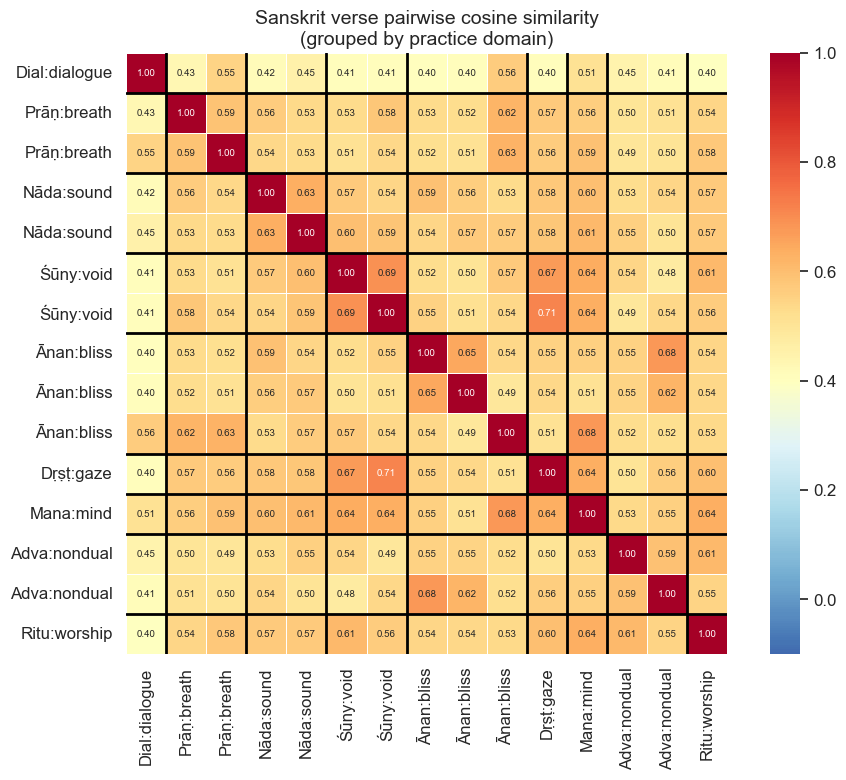

In [4]:
# Sort verses by domain so same-domain blocks are adjacent
domain_order = ["Dialogue", "Prāṇa", "Nāda", "Śūnyatā", "Ānanda", "Dṛṣṭi", "Manas", "Advaita", "Ritual"]
sorted_indices = sorted(range(len(VERSE_KEYS)), key=lambda i: domain_order.index(DOMAINS[i]))
sorted_keys = [VERSE_KEYS[i] for i in sorted_indices]
sorted_domains = [DOMAINS[i] for i in sorted_indices]
sorted_sa_embs = sa_embs[sorted_indices]

# Cosine similarity matrix (embeddings are already normalized)
sim_matrix = sorted_sa_embs @ sorted_sa_embs.T

# Short labels: domain + abbreviated key
labels = [f"{d[:4]}:{k.split('_')[0]}" for k, d in zip(sorted_keys, sorted_domains)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix, xticklabels=labels, yticklabels=labels,
    cmap="RdYlBu_r", vmin=-0.1, vmax=1.0, center=0.4,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Sanskrit verse pairwise cosine similarity\n(grouped by practice domain)", fontsize=14)

# Draw domain group boundaries
boundaries = []
prev = sorted_domains[0]
for i, d in enumerate(sorted_domains):
    if d != prev:
        boundaries.append(i)
        prev = d
for b in boundaries:
    ax.axhline(b, color="black", linewidth=2)
    ax.axvline(b, color="black", linewidth=2)

plt.tight_layout()
plt.show()

## 4. Cross-lingual similarity matrix

Each row is a Sanskrit verse, each column is an English translation. A strong diagonal means BGE-M3 correctly maps each verse to its own translation across scripts. Off-diagonal values show cross-verse, cross-lingual leakage.

In [ ]:
# Sanskrit × English cross-lingual similarity
cross_sim = sa_embs @ en_embs.T  # (15, 15)

# Use short verse key labels
short_labels = [k.replace("_", "\n", 1) for k in VERSE_KEYS]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cross_sim, xticklabels=short_labels, yticklabels=short_labels,
    cmap="RdYlBu_r", vmin=-0.1, vmax=1.0, center=0.3,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.5, ax=ax,
)
ax.set_xlabel("English translations", fontsize=12)
ax.set_ylabel("Sanskrit originals", fontsize=12)
ax.set_title("Cross-lingual cosine similarity: Sanskrit × English\n(diagonal = same verse across scripts)", fontsize=14)

# Highlight the diagonal
for i in range(len(VERSE_KEYS)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="black", linewidth=2.5))

plt.tight_layout()
plt.show()

# Report diagonal vs off-diagonal stats
diag = np.diag(cross_sim)
off_diag = cross_sim[~np.eye(len(VERSE_KEYS), dtype=bool)]
print(f"Diagonal (same verse):     mean={diag.mean():.3f}, min={diag.min():.3f}, max={diag.max():.3f}")
print(f"Off-diagonal (different):  mean={off_diag.mean():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}")
print(f"Diagonal dominance gap:    {diag.mean() - off_diag.mean():.3f}")

## 5. PCA projection — all 30 embeddings in 2D

Project all Sanskrit + English embeddings into 2D via PCA. Points are colored by practice domain, shaped by language. If the model captures both meaning and cross-lingual alignment, same-domain points should cluster and Sanskrit-English pairs should sit close together.

In [ ]:
# Stack all embeddings: Sanskrit first, then English
all_embs = np.vstack([sa_embs, en_embs])  # (30, 1024)
all_domains = DOMAINS + DOMAINS
all_langs = ["Sanskrit"] * len(VERSE_KEYS) + ["English"] * len(VERSE_KEYS)
all_keys = VERSE_KEYS + VERSE_KEYS

pca = PCA(n_components=2)
coords = pca.fit_transform(all_embs)

df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "domain": all_domains,
    "lang": all_langs,
    "key": all_keys,
})

# Domain color palette
domain_colors = {
    "Dialogue": "#95a5a6", "Prāṇa": "#e74c3c", "Nāda": "#3498db",
    "Śūnyatā": "#2ecc71", "Ānanda": "#f39c12", "Dṛṣṭi": "#9b59b6",
    "Manas": "#1abc9c", "Advaita": "#e67e22", "Ritual": "#34495e",
}

fig, ax = plt.subplots(figsize=(12, 9))

# Plot each combination of domain × lang
for domain in domain_order:
    sub = df[df["domain"] == domain]
    for lang, marker in [("Sanskrit", "o"), ("English", "s")]:
        pts = sub[sub["lang"] == lang]
        if pts.empty:
            continue
        ax.scatter(
            pts["PC1"], pts["PC2"],
            c=domain_colors[domain], marker=marker, s=120,
            edgecolors="black", linewidth=0.8, zorder=3,
            label=f"{domain} ({lang[:2]})",
        )

# Draw lines connecting Sanskrit-English pairs
for i in range(len(VERSE_KEYS)):
    ax.plot(
        [coords[i, 0], coords[i + len(VERSE_KEYS), 0]],
        [coords[i, 1], coords[i + len(VERSE_KEYS), 1]],
        color=domain_colors[DOMAINS[i]], alpha=0.3, linewidth=1, linestyle="--", zorder=1,
    )

# Annotate a few key points
for i, key in enumerate(VERSE_KEYS):
    if key in ("breath_ascending", "sound_anahata", "void_triple", "bliss_union", "nondual_i_am_shiva", "dialogue"):
        ax.annotate(
            key.split("_")[0], (coords[i, 0], coords[i, 1]),
            textcoords="offset points", xytext=(8, 8), fontsize=8, alpha=0.7,
        )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of VBT embeddings — 15 verses × 2 languages\n(circles = Sanskrit, squares = English, dashed = cross-lingual pairs)", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1, frameon=True)
plt.tight_layout()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

## 6. Ingest into pgvector + cross-lingual retrieval

Now exercise the full chunk-embed pipeline: build text-chunker JSON documents, parse, embed, store in PostgreSQL, and search using `search_chunks()`.

In [ ]:
def _build_doc(lang: str) -> dict:
    """Build a text-chunker-style JSON doc from VERSES."""
    text_key = "sa" if lang == "sanskrit" else "en"
    chunks = []
    for i, (key, v) in enumerate(VERSES.items()):
        chunks.append({
            "text": v[text_key],
            "chunk_type": "paragraph",
            "heading_context": ["Vijñāna Bhairava Tantra", v["domain"]],
            "heading_level": None,
            "page_number": None,
            "source_line_start": i * 2 + 1,
            "source_line_end": i * 2 + 2,
        })
    return {"total_chunks": len(chunks), "mode": "document", "chunks": chunks}

conn = psycopg.connect(DB_URL, autocommit=False)
register_vector(conn)
ensure_schema(conn)

# Parse, embed, and store both documents
for label, source in [("sanskrit", "/test/vbt_sanskrit.md"), ("english", "/test/vbt_english.md")]:
    doc = _build_doc(label)
    parsed = parse_chunks(json.dumps(doc))
    embeddings = embed_chunks(parsed.chunks, embedder, batch_size=32)
    doc_id = upsert_document(conn, source, parsed.mode, parsed.total_chunks)
    insert_chunks(conn, doc_id, parsed.chunks, embeddings)

chunk_count = conn.execute("SELECT count(*) FROM chunks").fetchone()[0]
print(f"Stored {chunk_count} chunks across 2 documents")

## 7. Retrieval bar charts — English query → ranked Sanskrit results

Four English queries, each targeting a different practice domain. The bar charts show the top-5 Sanskrit results ranked by cosine similarity, colored by domain. The target verse should appear at or near rank 1.

In [ ]:
queries = [
    ("breath ascending descending prāṇa life force", "Prāṇa"),
    ("unstruck sound flowing river inner ear nāda", "Nāda"),
    ("body emptiness void thought-free śūnyatā", "Śūnyatā"),
    ("I am all-pervading Shiva supreme lord", "Advaita"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (query_text, target_domain) in zip(axes.flat, queries):
    q_emb = embedder.embed([query_text])[0]
    results = search_chunks(conn, q_emb, top_k=5, source_path="/test/vbt_sanskrit.md")

    labels = []
    sims = []
    colors = []
    for r in results:
        # Find the verse key by matching text
        matched_key = next((k for k, v in VERSES.items() if v["sa"] == r.text), "?")
        matched_domain = VERSES.get(matched_key, {}).get("domain", "?")
        labels.append(matched_key.replace("_", "\n"))
        sims.append(r.similarity)
        colors.append(domain_colors.get(matched_domain, "#bdc3c7"))

    y_pos = np.arange(len(labels))
    bars = ax.barh(y_pos, sims, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Cosine similarity")
    ax.set_title(f'"{query_text[:40]}..."', fontsize=10, style="italic")
    ax.invert_yaxis()

    # Annotate similarity values
    for bar, sim in zip(bars, sims):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{sim:.3f}", va="center", fontsize=9)

fig.suptitle("Cross-lingual retrieval: English query → top-5 Sanskrit verses\n(bar color = practice domain)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Reverse retrieval — Sanskrit query → ranked English translations

The mirror test: query in Devanagari keywords or full Sanskrit verses, retrieve from the English translations document. This validates that cross-lingual alignment works in both directions — not just English→Sanskrit.

In [ ]:
sa_queries = [
    ("प्राण जीव उत्पत्ति भरण", "breath_ascending", "Prāṇa"),
    ("अनाहत शब्द नाद ब्रह्म", "sound_anahata", "Nāda"),
    ("शून्य निर्विकल्प देह", "void_body_sky", "Śūnyatā"),
    ("सर्वज्ञ व्यापक परमेश्वर शिव", "nondual_i_am_shiva", "Advaita"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (query_text, target_key, target_domain) in zip(axes.flat, sa_queries):
    q_emb = embedder.embed([query_text])[0]
    results = search_chunks(conn, q_emb, top_k=5, source_path="/test/vbt_english.md")

    labels = []
    sims = []
    colors = []
    for r in results:
        matched_key = next((k for k, v in VERSES.items() if v["en"] == r.text), "?")
        matched_domain = VERSES.get(matched_key, {}).get("domain", "?")
        labels.append(matched_key.replace("_", "\n"))
        sims.append(r.similarity)
        colors.append(domain_colors.get(matched_domain, "#bdc3c7"))

    y_pos = np.arange(len(labels))
    bars = ax.barh(y_pos, sims, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Cosine similarity")
    ax.set_title(f'"{query_text}"', fontsize=11)
    ax.invert_yaxis()

    for bar, sim in zip(bars, sims):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{sim:.3f}", va="center", fontsize=9)

fig.suptitle("Reverse retrieval: Sanskrit keyword query → top-5 English translations\n(bar color = practice domain)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Full Sanskrit verse as query → its own English translation should rank #1
test_keys = ["nondual_i_am_shiva", "bliss_union", "sound_anahata", "void_triple", "breath_ascending"]

rows = []
for key in test_keys:
    q_emb = embedder.embed([VERSES[key]["sa"]])[0]
    results = search_chunks(conn, q_emb, top_k=3, source_path="/test/vbt_english.md")
    target_en = VERSES[key]["en"]
    rank = next((i + 1 for i, r in enumerate(results) if r.text == target_en), None)
    top_sim = results[0].similarity if results else 0.0
    correct_sim = next((r.similarity for r in results if r.text == target_en), 0.0)
    rows.append({
        "verse": key,
        "domain": VERSES[key]["domain"],
        "own_translation_rank": rank,
        "own_translation_sim": correct_sim,
        "top_result_sim": top_sim,
        "hit": "yes" if rank == 1 else ("top 3" if rank and rank <= 3 else "miss"),
    })

result_df = pd.DataFrame(rows)
print("Full Sanskrit verse → English translation retrieval:")
print(result_df.to_string(index=False))
print(f"\nRank-1 hits: {sum(1 for r in rows if r['hit'] == 'yes')}/{len(rows)}")

## 9. Monolingual retrieval — Sanskrit query → Sanskrit results

Query in Devanagari, retrieve from the same Sanskrit document. This tests whether the model captures thematic similarity *within* a single script — keyword queries should surface same-domain verses, and a full verse should find its thematic neighbor (not the dialogue marker).

In [ ]:
sa_mono_queries = [
    ("प्राण जीव श्वास मरुत", "Prāṇa", {"breath_ascending", "breath_middle"}),
    ("शब्द नाद अनाहत तन्त्री", "Nāda", {"sound_anahata", "sound_instruments"}),
    ("शून्य निर्विकल्प पृष्ठ मूल हृदय", "Śūnyatā", {"void_body_sky", "void_triple"}),
    ("सुख आनन्द शक्ति ब्रह्म", "Ānanda", {"bliss_union", "bliss_meeting", "bliss_vikalpa_free"}),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (query_text, target_domain, expected_keys) in zip(axes.flat, sa_mono_queries):
    q_emb = embedder.embed([query_text])[0]
    results = search_chunks(conn, q_emb, top_k=5, source_path="/test/vbt_sanskrit.md")

    labels = []
    sims = []
    colors = []
    edge_colors = []
    for r in results:
        matched_key = next((k for k, v in VERSES.items() if v["sa"] == r.text), "?")
        matched_domain = VERSES.get(matched_key, {}).get("domain", "?")
        labels.append(matched_key.replace("_", "\n"))
        sims.append(r.similarity)
        colors.append(domain_colors.get(matched_domain, "#bdc3c7"))
        # Highlight expected hits with a thick green border
        edge_colors.append("#27ae60" if matched_key in expected_keys else "black")

    y_pos = np.arange(len(labels))
    bars = ax.barh(y_pos, sims, color=colors, edgecolor=edge_colors,
                   linewidth=[2.5 if e == "#27ae60" else 0.6 for e in edge_colors])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Cosine similarity")
    ax.set_title(f'"{query_text}"', fontsize=11)
    ax.invert_yaxis()

    for bar, sim in zip(bars, sims):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{sim:.3f}", va="center", fontsize=9)

fig.suptitle("Monolingual retrieval: Sanskrit query → top-5 Sanskrit verses\n(green border = expected domain hit)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Full verse as query → nearest non-self Sanskrit neighbor
# Same-domain verse should be the nearest neighbor, dialogue marker should be far
probe_keys = list(VERSES.keys())

rows = []
for key in probe_keys:
    q_emb = embedder.embed([VERSES[key]["sa"]])[0]
    results = search_chunks(conn, q_emb, top_k=15, source_path="/test/vbt_sanskrit.md")
    non_self = [r for r in results if r.text != VERSES[key]["sa"]]

    if non_self:
        best = non_self[0]
        best_key = next((k for k, v in VERSES.items() if v["sa"] == best.text), "?")
        best_domain = VERSES.get(best_key, {}).get("domain", "?")
    else:
        best_key, best_domain, best = "—", "—", None

    rows.append({
        "query": key,
        "query_domain": VERSES[key]["domain"],
        "nearest_neighbor": best_key,
        "nn_domain": best_domain,
        "similarity": f"{best.similarity:.3f}" if best else "—",
        "same_domain": "yes" if VERSES[key]["domain"] == best_domain else "",
    })

nn_df = pd.DataFrame(rows)
print("Full Sanskrit verse → nearest non-self Sanskrit neighbor:")
print(nn_df.to_string(index=False))

same_domain_hits = sum(1 for r in rows if r["same_domain"] == "yes")
print(f"\nSame-domain nearest neighbor: {same_domain_hits}/{len(rows)}")

## 10. Similarity distribution — within-domain vs. cross-domain

A violin/box plot comparing cosine similarities for verse pairs within the same practice domain vs. across different domains. Clear separation confirms thematic clustering in the embedding space.

In [ ]:
# Collect all pairwise similarities, labeled as within-domain or cross-domain
# Use both Sanskrit and English embeddings for richer statistics
pair_data = []
for embs, lang in [(sa_embs, "Sanskrit"), (en_embs, "English")]:
    sim = embs @ embs.T
    for i in range(len(VERSE_KEYS)):
        for j in range(i + 1, len(VERSE_KEYS)):
            same = DOMAINS[i] == DOMAINS[j]
            pair_data.append({
                "similarity": float(sim[i, j]),
                "pair_type": "Within domain" if same else "Cross domain",
                "lang": lang,
            })

# Add cross-lingual same-verse pairs (diagonal of cross_sim)
for i in range(len(VERSE_KEYS)):
    pair_data.append({
        "similarity": float(cross_sim[i, i]),
        "pair_type": "Cross-lingual\n(same verse)",
        "lang": "Sa-En",
    })

pdf = pd.DataFrame(pair_data)

fig, ax = plt.subplots(figsize=(8, 5))
order = ["Within domain", "Cross domain", "Cross-lingual\n(same verse)"]
palette = {"Within domain": "#2ecc71", "Cross domain": "#e74c3c", "Cross-lingual\n(same verse)": "#3498db"}

sns.violinplot(data=pdf, x="pair_type", y="similarity", order=order, palette=palette,
               inner="box", cut=0, ax=ax)
sns.stripplot(data=pdf, x="pair_type", y="similarity", order=order,
              color="black", alpha=0.15, size=3, jitter=True, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Cosine similarity")
ax.set_title("Similarity distributions: within-domain vs. cross-domain vs. cross-lingual", fontsize=12)
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
for pt in order:
    sub = pdf[pdf["pair_type"] == pt]["similarity"]
    print(f"{pt:30s}  mean={sub.mean():.3f}  std={sub.std():.3f}  n={len(sub)}")

## 11. Threshold sweep — precision vs. recall tradeoff

Sweep `threshold` from 0.0 to 0.9 and observe how many results `search_chunks()` returns. This visualizes the precision/recall tradeoff that the `--threshold` CLI flag controls.

In [ ]:
thresholds = np.arange(0.0, 0.95, 0.05)
sweep_queries = [
    ("breath prāṇa ascending life force", "Prāṇa query"),
    ("I am Shiva all-pervading lord", "Advaita query"),
    ("meditation practice yoga contemplation", "Generic query"),
]

fig, ax = plt.subplots(figsize=(9, 5))

for query_text, label in sweep_queries:
    q_emb = embedder.embed([query_text])[0]
    counts = []
    for t in thresholds:
        results = search_chunks(conn, q_emb, top_k=30, threshold=float(t))
        counts.append(len(results))
    ax.plot(thresholds, counts, marker="o", markersize=4, label=label, linewidth=2)

ax.set_xlabel("Similarity threshold")
ax.set_ylabel("Number of results returned")
ax.set_title("Threshold sweep: results count vs. minimum similarity", fontsize=13)
ax.legend()
ax.set_xlim(-0.02, 0.95)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 12. Cleanup

Roll back the transaction so no test data persists in the database.

In [ ]:
conn.rollback()
conn.close()
print("Rolled back all test data. Database is clean.")